In [1]:
import Util.ExploratoryDataAnalysis
import Util.ModelDevelopment
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    roc_curve
)

from sklearn.calibration import calibration_curve, CalibratedClassifierCV


In [2]:
data_dir = Path("data")

dfs = [
    Util.ExploratoryDataAnalysis.load_battles_file_to_df(file)
    for file in data_dir.glob("*.json")
]

df = pd.concat(dfs, ignore_index=True)

df = pd.get_dummies(df, columns=['result'])

print(df.shape)
df.head()

(430591, 28)


,battleTime,gameModeId,playerTag,opponentTag,playerCrowns,opponentCrowns,crown_diff,p_card_1,o_card_1,p_card_2,...,o_card_6,p_card_7,o_card_7,p_card_8,o_card_8,p_card_9,o_card_9,result_draw,result_loss,result_win
0,20260303T044817.000Z,72000006,#9CVVPULRY,#9RRRV9PLP,1,0,1,26000007,26000017,26000011,...,26000004,26000021,26000043,28000007,28000011,159000000,159000000,0,0,1
1,20260303T040122.000Z,72000006,#9CVVPULRY,#2200YRUGGU,3,0,3,26000007,27000013,26000011,...,28000026,26000021,28000013,28000007,26000101,159000000,159000000,0,0,1
2,20260303T035814.000Z,72000006,#9CVVPULRY,#VYGPRCQLJ,0,1,-1,26000007,26000011,26000011,...,28000004,26000021,26000021,28000007,28000001,159000000,159000000,0,1,0
3,20260303T034754.000Z,72000006,#9CVVPULRY,#2LRLG2C28,1,0,1,26000007,26000064,26000011,...,26000048,26000021,28000003,28000007,26000042,159000000,159000000,0,0,1
4,20260303T034441.000Z,72000006,#9CVVPULRY,#8UJQQCQR,1,0,1,26000007,26000007,26000011,...,28000015,26000021,26000005,28000007,26000044,159000000,159000000,0,0,1


In [3]:
# Get the list of all the cards in the game from Clash Royale API
cards_df = Util.ExploratoryDataAnalysis.fetch_all_cards()

display(cards_df)

,name,id,maxLevel,maxEvolutionLevel,elixirCost,rarity,is_support
0,Knight,26000000,16,3.0,3.0,common,False
1,Archers,26000001,16,1.0,3.0,common,False
2,Goblins,26000002,16,2.0,2.0,common,False
3,Giant,26000003,14,2.0,5.0,rare,False
4,P.E.K.K.A,26000004,11,1.0,7.0,epic,False
...,...,...,...,...,...,...,...
120,Vines,28000026,11,NaN,3.0,epic,False
121,Tower Princess,159000000,16,NaN,NaN,common,True
122,Cannoneer,159000001,11,NaN,NaN,epic,True
123,Dagger Duchess,159000002,8,NaN,NaN,legendary,True


In [4]:
X, y, artifacts = Util.ModelDevelopment.build_features_and_target(df, cards_df, n_cards_per_side=9, return_artifacts=True)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print(X.shape)
X.head()

(430591, 267)


,gameModeId,hour,day_of_week,p_has_26000000,p_has_26000001,p_has_26000002,p_has_26000003,p_has_26000004,p_has_26000005,p_has_26000006,...,p_building_count,o_avg_elixir,o_total_elixir,o_troop_count,o_spell_count,o_building_count,avg_elixir_diff,spell_diff,building_diff,troop_diff
0,72000006,4,1,0,0,0,0,0,0,0,...,1,4.714286,33.0,5,3,0,-1.339286,-1,1,0
1,72000006,4,1,0,0,0,0,0,0,0,...,1,4.000000,32.0,4,2,2,-0.625000,0,-1,1
2,72000006,3,1,0,0,0,0,0,0,0,...,1,3.125000,25.0,6,2,0,0.250000,0,1,-1
3,72000006,3,1,0,0,0,0,0,0,0,...,1,4.750000,38.0,7,1,0,-1.375000,1,1,-2
4,72000006,3,1,0,0,0,0,0,0,0,...,1,4.000000,32.0,7,1,0,-0.625000,1,1,-2


Tree range:  200
Tree range:  400
Tree range:  700
Tree range:  1000


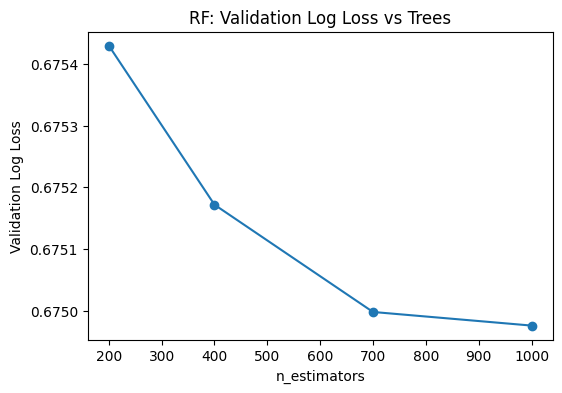

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

tree_range = [200, 400, 700, 1000]
losses = []

for n in tree_range:
    print("Tree range: ", n)
    rf = RandomForestClassifier(
        n_estimators=n,
        max_depth=30,
        min_samples_leaf=5,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train, y_train)
    p = rf.predict_proba(X_val)[:, 1]
    losses.append(log_loss(y_val, p))

plt.figure(figsize=(6,4))
plt.plot(tree_range, losses, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Validation Log Loss")
plt.title("RF: Validation Log Loss vs Trees")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# 3-way split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)


In [16]:
def eval_probs(y_true, p, name="model"):
    return {
        "model": name,
        "log_loss": log_loss(y_true, p),
        "brier": brier_score_loss(y_true, p),
        "roc_auc": roc_auc_score(y_true, p),
    }

def plot_roc(y_true, p, title="ROC"):
    fpr, tpr, _ = roc_curve(y_true, p)
    auc = roc_auc_score(y_true, p)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_calibration(y_true, p, title="Calibration Curve", n_bins=15):
    prob_true, prob_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="uniform")
    plt.figure(figsize=(6,6))
    plt.plot(prob_pred, prob_true, marker="o", label="Model")
    plt.plot([0,1],[0,1],'--', label="Perfect")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.legend()
    plt.show()

In [20]:
rf = RandomForestClassifier(
    n_estimators=700,
    random_state=42,
    n_jobs=1
)

param_dist = {
    "max_depth": [10, 15, 20],
    "min_samples_leaf": [2, 3, 5],
    "min_samples_split": [5, 10, 15],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True],
    "max_samples": [0.6, 0.8]
}

search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=10,
    scoring="neg_log_loss",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_

print("Best params:", search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, max_samples=0.6, min_samples_leaf=3, min_samples_split=10; total time= 2.5min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, max_samples=0.6, min_samples_leaf=3, min_samples_split=10; total time= 2.5min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, max_samples=0.8, min_samples_leaf=2, min_samples_split=10; total time= 2.9min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, max_samples=0.8, min_samples_leaf=2, min_samples_split=10; total time= 2.9min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, max_samples=0.8, min_samples_leaf=2, min_samples_split=10; total time= 2.9min
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, max_samples=0.6, min_samples_leaf=3, min_samples_split=10; total time= 2.6min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, max_samples=0.6, min_samples_leaf=3, min_samples_split=15; total 

In [21]:
from sklearn.calibration import CalibratedClassifierCV

cal_rf = CalibratedClassifierCV(
    best_rf,
    method="isotonic",
    cv=3
)

cal_rf.fit(X_train, y_train)

CalibratedClassifierCV(cv=3,
                       estimator=RandomForestClassifier(max_depth=20,
                                                        max_samples=0.8,
                                                        min_samples_leaf=2,
                                                        min_samples_split=15,
                                                        n_estimators=700,
                                                        n_jobs=1,
                                                        random_state=42),
                       method='isotonic')

In [22]:
test_probs = cal_rf.predict_proba(X_test)[:,1]

from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

print("Test Log Loss:", log_loss(y_test, test_probs))
print("Test Brier Score:", brier_score_loss(y_test, test_probs))
print("Test ROC AUC:", roc_auc_score(y_test, test_probs))

Test Log Loss: 0.6763163789347001
Test Brier Score: 0.241741202553531
Test ROC AUC: 0.5859571757023558


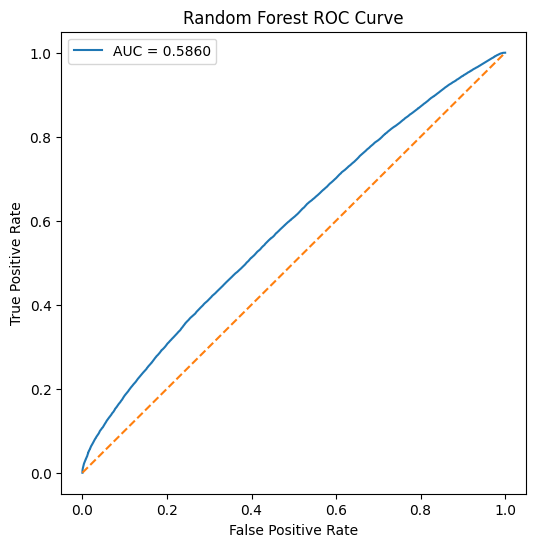

In [23]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_probs):.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

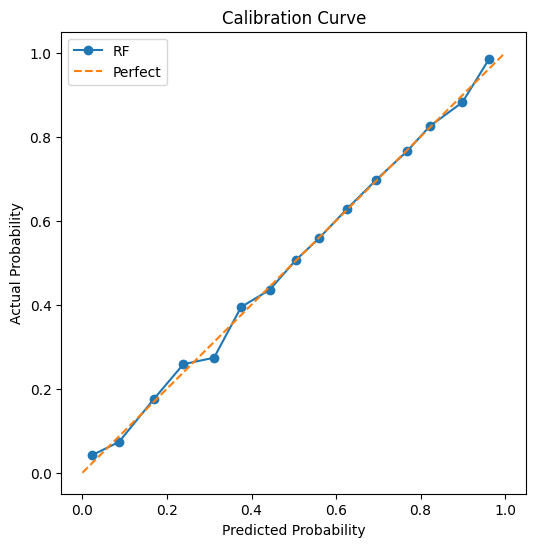

In [24]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    test_probs,
    n_bins=15
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="RF")
plt.plot([0,1],[0,1],'--', label="Perfect")

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")

plt.legend()
plt.show()